# Multi-Factor Momentum Trading Strategy

### Part 1: Market Regime Filter
- #### Mechanism: It checks if the market index (e.g., SPY) is trading above its 200-day Simple Moving Average (SMA).
- #### Action: Long positions are only initiated or held if the market is in a bullish regime (price > 200-day SMA). If the market enters a bearish regime, all positions are exited to mitigate systemic risk.

In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
TABLE_INDEX = 0  # first table on the page is the constituent list
TICKER_COL = "Symbol"

headers = {"User-Agent": "Mozilla/5.0"}  # wikipedia blocks default requests UA sometimes
resp = requests.get(WIKI_URL, headers=headers, timeout=15)

tables = pd.read_html(StringIO(resp.text))

df = tables[TABLE_INDEX]

tickers = df[TICKER_COL].astype(str).str.strip().tolist()
tickers = [t.replace(".", "-") for t in tickers]
tickers = sorted(set(tickers))
len(tickers)

503

In [2]:
# Doing a small sample for now
# import random
# random.seed(42)
# random.shuffle(tickers)
# tickers = tickers[:75]

In [3]:
if 'SPY' not in tickers: tickers += ['SPY']

In [4]:
import yfinance as yf
import datetime as dt

N_YEARS = 10
period = dict(
    start = dt.datetime.today() - dt.timedelta(days=365 * N_YEARS)
    , end   = dt.datetime.today()
)

data = yf.download(tickers, **period)

data.tail()

[*********************100%***********************]  504 of 504 completed


Price            Close                                                 \
Ticker               A        AAPL        ABBV        ABNB        ABT   
Date                                                                    
2026-07-08  129.070007  313.390015  252.740005  142.949997  95.180000   
2026-07-09  133.589996  316.220001  249.910004  146.889999  94.400002   
2026-07-10  134.289993  315.320007  248.080002  148.619995  93.930000   
2026-07-13  134.039993  317.309998  248.000000  146.330002  92.110001   
2026-07-14  135.199997  314.859985  244.779999  146.539993  88.959999   

Price                                                                  ...  \
Ticker            ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                   ...   
2026-07-08  102.010002  135.559998  220.940002  385.399994  80.290001  ...   
2026-07-09  101.699997  139.059998  222.649994  393.640015  78.980003  ...   
2026-07-10  101.059998  135.229996  223.639999  395.649994  80.410004  ...   
2026-07-13  103.059998  138.520004  230.610001  386.010010  82.040001  ...   
2026-07-14  101.529999  134.559998  220.779999  392.750000  82.279999  ...   

Price        Volume                                                         \
Ticker           WY     WYNN      XEL       XOM      XYL      XYZ      YUM   
Date                                                                         
2026-07-08  5406900  1313400  4365200  18291400  1779800  4932800  2540800   
2026-07-09  4091600  1344500  5013100  14110200  1337400  3047100  4252900   
2026-07-10  6523600  1327000  3537600   9753500  1399600  3664300  1847100   
2026-07-13  3864900  1287000  4476900  18724300  1507100  3927800  2222600   
2026-07-14  5330713  1255439  3074996  15581936  1107411  4914087  4072899   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2026-07-08  1615500  373500  4838000  
2026-07-09  1809800  642500  5611300  
2026-07-10  1543100  593100  5157700  
2026-07-13  2724800  730400  6093600  
2026-07-14  2736630  441881  3960074  

[5 rows x 2520 columns]

In [5]:
assert not data.empty

In [6]:
assert not data.Close.isna().all(axis=0).sum()

In [7]:
assert not data.Close.isna().all(axis=1).sum()

In [8]:
# Market Regime Filter
LOOKBACK_REGIME = 200
spy_sma_200 = data.Close.SPY.rolling(LOOKBACK_REGIME).mean()
mrf_signal = data.Close.SPY < spy_sma_200

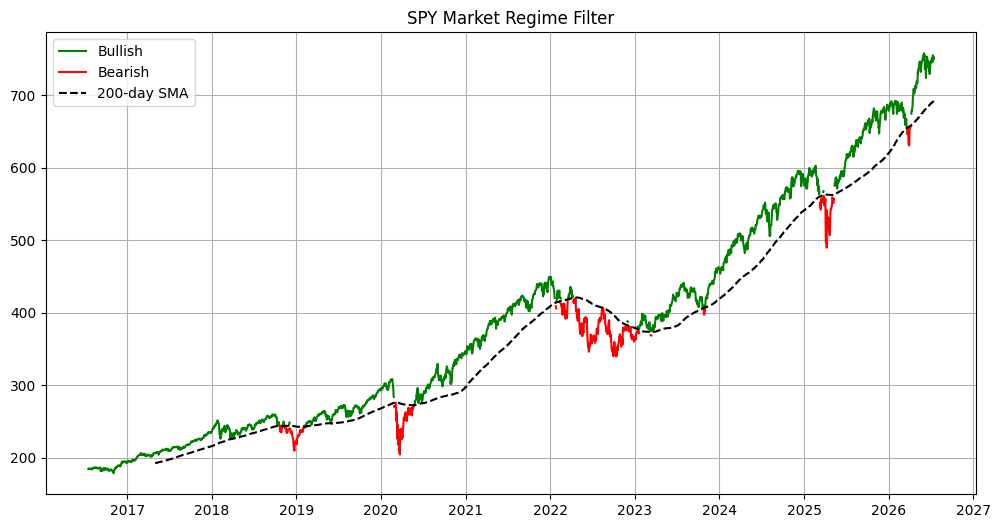

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot SPY price when filter is ON (green)
plt.plot(
    data.index,
    data.Close.SPY.where(~mrf_signal),
    color="green",
    label="Bullish"
)

# Plot SPY price when filter is OFF (red)
plt.plot(
    data.index,
    data.Close.SPY.where(mrf_signal),
    color="red",
    label="Bearish"
)

# Optional: plot the 200-day SMA
plt.plot(
    data.index,
    spy_sma_200,
    color="black",
    linestyle="--",
    label="200-day SMA"
)

plt.title("SPY Market Regime Filter")
plt.legend()
plt.grid(True)
plt.show()

### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
- #### Mechanism: A stock is only considered a candidate for investment if it is trading above its own 200-day SMA.

In [10]:
LOOK_BACK_TSMOM = 200
def sma_200(x: pd.Series) -> pd.Series:
    return x.rolling(LOOK_BACK_TSMOM).mean()

data_sma_200d = data.Close.apply(sma_200)
data_sma_200d.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-08,130.185371,271.439759,220.338952,130.423825,110.409577,93.83965,215.210328,286.56795,318.160658,66.994660,...,23.806226,112.020122,77.888994,134.715910,129.711906,67.36885,152.679021,91.173668,249.04660,115.548827
2026-07-09,130.226749,271.796822,220.501943,130.523075,110.212002,93.90615,214.731326,285.85170,318.913669,67.088160,...,23.801394,111.871109,77.931589,134.851449,129.599151,67.37080,152.772943,91.124578,248.81715,115.203583
2026-07-10,130.271577,272.096634,220.655198,130.638975,110.009223,93.97130,214.231754,285.14950,319.666774,67.197561,...,23.800533,111.744027,77.978212,134.998000,129.494779,67.37025,152.854819,91.077874,248.60270,114.866815
2026-07-13,130.317090,272.414623,220.807954,130.753125,109.800936,94.04430,213.770628,284.49365,320.374453,67.311005,...,23.798888,111.596495,78.023561,135.163263,129.392485,67.38115,152.926558,91.052044,248.36600,114.539275
2026-07-14,130.376141,272.730932,220.957407,130.870425,109.586743,94.09815,213.272164,283.83120,321.106767,67.421836,...,23.798074,111.450709,78.043455,135.328442,129.300058,67.39865,152.980747,91.017447,248.12415,114.209778


In [11]:
tsmom_filter = data.Close.gt(data_sma_200d)

<Axes: title={'center': 'Number of Stocks Above 200-Day SMA'}, xlabel='Date', ylabel='Number of Valid Stocks'>

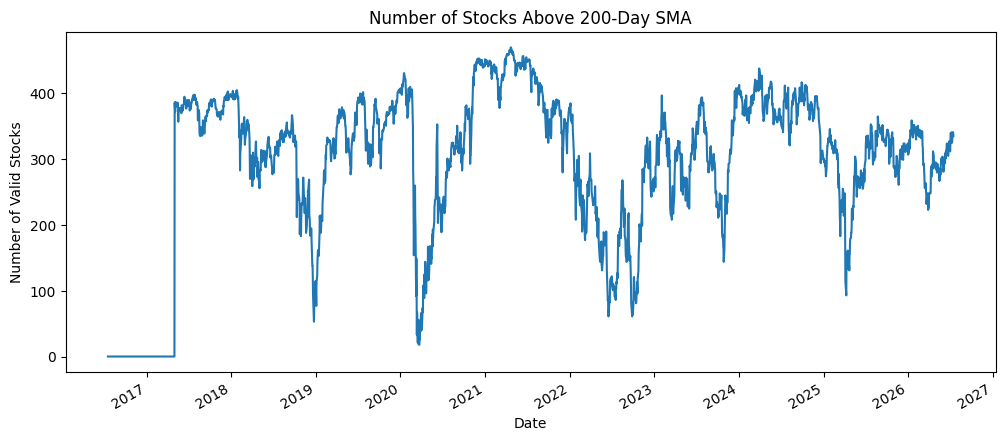

In [12]:
valid_stocks = tsmom_filter.sum(axis=1)

valid_stocks.plot(
    figsize=(12, 5),
    title="Number of Stocks Above 200-Day SMA",
    ylabel="Number of Valid Stocks",
    xlabel="Date"
)

### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
- #### Mechanism: Momentum is calculated over multiple lookback periods (60, 120, and 252 days) and then averaged to produce a robust momentum score.

In [13]:

cross_sect_mom_lookbacks = [60, 120, 252]
LOOKBACK_CSM = max(cross_sect_mom_lookbacks)

def cross_sect_mom(prices: pd.DataFrame, lookbacks: list[int] = cross_sect_mom_lookbacks) -> pd.DataFrame:
    # average raw return signal per asset, per lookback
    raw_signal = pd.concat(
        [(prices / prices.shift(l)) - 1 for l in lookbacks]
    ).groupby(level=0).mean()  # or however you're aligning — see note below
    return raw_signal

    # cross-sectional z-score: rank/normalize ACROSS assets at each date
    # z = raw_signal.sub(raw_signal.mean(axis=1), axis=0).div(raw_signal.std(axis=1), axis=0)
    # return z

csm_data = cross_sect_mom(data.Close)
csm_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-08,0.033592,0.301858,0.260043,0.057492,-0.181408,0.109187,-0.424452,-0.240181,0.342560,0.320953,...,-0.091966,-0.100352,0.087093,0.124229,-0.101595,0.157232,0.071220,-0.034959,0.011493,-0.422191
2026-07-09,0.057099,0.317166,0.241669,0.101866,-0.190160,0.096258,-0.434908,-0.252962,0.361250,0.290681,...,-0.111885,-0.095313,0.082625,0.072943,-0.100777,0.175587,0.051241,-0.030550,0.029508,-0.429021
2026-07-10,0.054902,0.314054,0.232274,0.105723,-0.193333,0.103752,-0.445033,-0.238949,0.369130,0.312261,...,-0.075644,-0.094605,0.101751,0.095403,-0.094923,0.159793,0.049083,-0.015629,0.033947,-0.426741
2026-07-13,0.057795,0.311976,0.223239,0.084058,-0.209428,0.119327,-0.431057,-0.219261,0.333832,0.350565,...,-0.072943,-0.119695,0.107784,0.133804,-0.086485,0.165547,0.034466,0.027958,0.010161,-0.426942
2026-07-14,0.083527,0.324047,0.212570,0.088986,-0.213874,0.102489,-0.435281,-0.247456,0.358661,0.339125,...,-0.059978,-0.121116,0.089558,0.128439,-0.067719,0.223333,0.038371,-0.000618,0.000304,-0.428670


<Axes: title={'center': 'Cross-Sectional Momentums'}, xlabel='Date'>

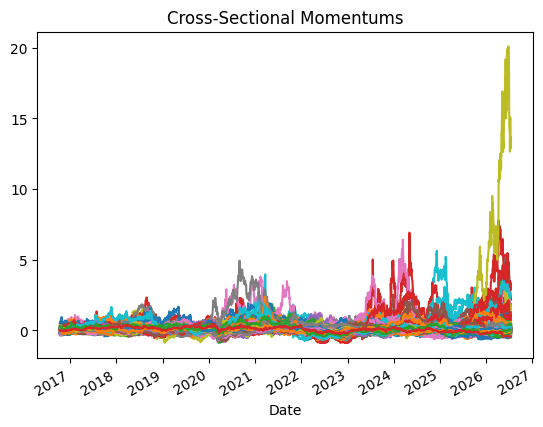

In [14]:
csm_data.plot(
    title='Cross-Sectional Momentums'
    , legend=False
)

### Part 4: Frog-in-the-Pan (FIP) Score: This factor measures the quality and consistency of a stock's trend.
- #### Mechanism: It calculates the ratio of positive daily returns over a 252-day period. A higher score indicates a smoother, more consistent uptrend, rather than one driven by a few large, volatile spikes.


In [15]:
LOOK_BACK_FIP = 252
daily_ret = (data.Close / data.Close.shift(1)) - 1
is_positive = daily_ret > 0
# Return was positive how many days
positive_days_sum = is_positive.rolling(LOOK_BACK_FIP).sum()
# Ratio of positive return days/total days
fip_data = positive_days_sum / 252
fip_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-08,0.515873,0.531746,0.503968,0.539683,0.468254,0.535714,0.464286,0.464286,0.547619,0.523810,...,0.464286,0.448413,0.539683,0.555556,0.507937,0.503968,0.511905,0.519841,0.484127,0.464286
2026-07-09,0.515873,0.531746,0.500000,0.543651,0.468254,0.531746,0.464286,0.464286,0.547619,0.519841,...,0.464286,0.448413,0.539683,0.551587,0.507937,0.507937,0.507937,0.519841,0.484127,0.460317
2026-07-10,0.515873,0.527778,0.496032,0.547619,0.468254,0.531746,0.464286,0.468254,0.551587,0.523810,...,0.468254,0.452381,0.539683,0.555556,0.507937,0.503968,0.507937,0.519841,0.484127,0.460317
2026-07-13,0.511905,0.527778,0.492063,0.543651,0.464286,0.531746,0.468254,0.472222,0.547619,0.523810,...,0.464286,0.448413,0.539683,0.555556,0.503968,0.507937,0.503968,0.523810,0.480159,0.456349
2026-07-14,0.515873,0.527778,0.492063,0.547619,0.464286,0.531746,0.468254,0.472222,0.551587,0.523810,...,0.464286,0.448413,0.535714,0.555556,0.507937,0.511905,0.503968,0.523810,0.480159,0.456349


<Axes: title={'center': 'Frog in the Pan Scores'}, xlabel='Date'>

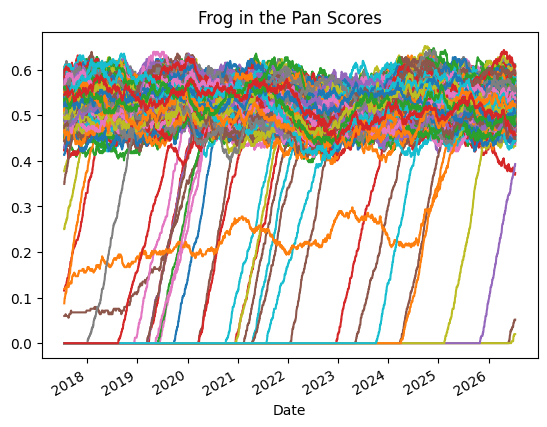

In [16]:
fip_data.plot(
    title='Frog in the Pan Scores'
    , legend=False
)

### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
- #### Mechanism: It calculates the rolling skewness of stock returns over a 90-day window. A high negative skew suggests a stock has a "tail" of large negative returns and is thus penalized in its final score.

In [17]:
LOOKBACK_SKEW = 90
log_returns = np.log(data.Close).diff()
skew_data = log_returns.rolling(LOOKBACK_SKEW).skew()
skew_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-08,2.808019,-0.439205,0.388453,-0.091427,0.043887,-0.389609,-2.057976,-0.179443,-0.389524,0.113821,...,-0.081288,0.302401,0.258824,-0.487788,-0.185447,1.105147,-0.292604,-1.597114,0.401325,-4.480937
2026-07-09,2.708186,-0.450673,0.424049,-0.127701,0.061271,-0.370741,-2.045757,-0.174801,-0.402760,0.157876,...,-0.084061,0.266614,0.271367,-0.459116,-0.218579,-0.063863,-0.247724,-1.652495,0.401295,-4.488152
2026-07-10,2.739583,-0.440061,0.453933,-0.165436,0.045184,-0.338267,-2.020511,-0.187038,-0.420594,0.145740,...,0.021845,0.331257,0.258407,-0.458606,-0.240162,-0.047912,-0.226583,-1.630113,0.401652,-4.507969
2026-07-13,2.754051,-0.460634,0.451409,-0.146618,0.062225,-0.357328,-2.014765,-0.195291,-0.423106,0.110430,...,0.036840,0.323060,0.230108,-0.406962,-0.266120,-0.088884,-0.228845,-1.624982,0.424224,-4.551516
2026-07-14,2.764270,-0.454409,0.486138,-0.127026,0.042529,-0.353220,-1.972511,-0.164127,-0.431226,0.089082,...,0.018498,0.358151,0.235269,-0.437378,-0.256671,-0.086652,-0.232662,-1.603214,0.468248,-4.525468


<Axes: title={'center': 'Skew'}, xlabel='Date'>

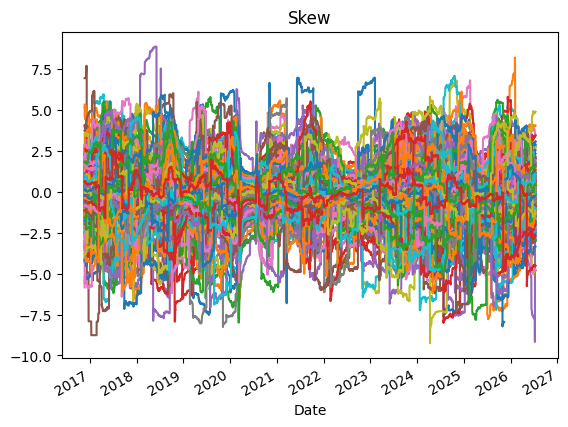

In [18]:
skew_data.plot(
    title='Skew'
    , legend=False
)

### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
- #### Mechanism: Once the top N stocks are selected, portfolio capital is allocated inversely proportional to each stock's historical volatility (standard deviation over 126 days). Less volatile stocks receive a larger capital allocation, and more volatile stocks receive a smaller one with the goal of equalizing the risk contribution of each position.

In [19]:
LOOKBACK_VOLATILITY = 126
vol_data = data.Close.rolling(LOOKBACK_VOLATILITY).std()
vol_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-08,10.432726,20.175445,13.108744,6.834517,11.716319,3.252473,40.470103,30.765083,45.609253,5.939937,...,1.084461,6.192476,2.594064,10.394995,10.442920,7.289524,4.721372,4.794586,18.457545,20.921649
2026-07-09,10.263392,20.482349,13.399591,6.923591,11.506007,3.299654,40.234085,29.997751,45.310616,5.871293,...,1.095386,6.079261,2.551892,10.134478,10.321254,7.351357,4.718475,4.773709,18.645821,21.021474
2026-07-10,10.091866,20.750369,13.616179,7.042050,11.301366,3.338465,40.041679,29.125332,45.006887,5.776347,...,1.089072,6.022877,2.488676,9.794807,10.217446,7.403500,4.715407,4.770165,18.901544,21.135017
2026-07-13,9.951174,21.028221,13.857151,7.115880,11.111923,3.406432,39.660265,28.125189,44.708558,5.743527,...,1.090233,5.956126,2.427706,9.516746,10.090882,7.479381,4.720807,4.774053,19.025095,21.234063
2026-07-14,9.766603,21.257656,14.039114,7.187997,10.939265,3.449003,39.308359,27.261332,44.450721,5.720761,...,1.088749,5.905356,2.379408,9.262197,9.977188,7.573707,4.717560,4.768566,19.031275,21.337700


<Axes: title={'center': 'Volatility'}, xlabel='Date'>

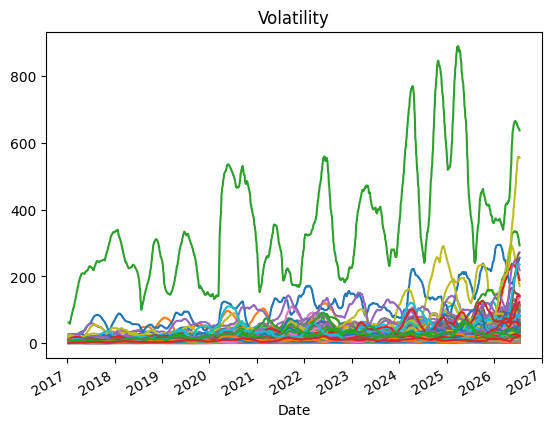

In [20]:
vol_data.plot(
    title='Volatility'
    , legend=False
)

In [21]:
UNIVERSE       : int = 0
MRF_SIGNAL    : int = 1
TSMOM_SIGNALS : int = 2
CSM_SIGNALS   : int = 3
FIP_SCORES    : int = 4
SKEWS         : int = 5
VOLS          : int = 6

strat_dat = (
    data.Close.columns
    , mrf_signal
    , tsmom_filter
    , csm_data
    , fip_data
    , skew_data
    , vol_data
)

# find tickers with any all-NaN column across all signal frames
bad_tickers = set()
for df in strat_dat[1:]:
    if hasattr(df, 'columns'):
        bad_tickers.update(df.columns[df.isna().all()])

print("Dropping tickers with no data:", bad_tickers)

# rebuild strat_dat with those tickers removed from every frame
clean_universe = [t for t in strat_dat[UNIVERSE] if t not in bad_tickers]
strat_dat = (
    pd.Index(clean_universe),
    mrf_signal,
    tsmom_filter.drop(columns=bad_tickers, errors='ignore'),
    csm_data.drop(columns=bad_tickers, errors='ignore'),
    fip_data.drop(columns=bad_tickers, errors='ignore'),
    skew_data.drop(columns=bad_tickers, errors='ignore'),
    vol_data.drop(columns=bad_tickers, errors='ignore'),
)

common_start = min(df.dropna().index[0] for df in strat_dat[1:])
datas = [d[common_start:] if i > 0 else d for i, d in enumerate(strat_dat)]

Dropping tickers with no data: {'FDXF', 'HONA'}


In [22]:
SELL_ALL_SIGNAL    : str = 'SELL_ALL_SIGNAL'
BASKET_EMPTY_SIGNAL: str = 'BASKET_EMPTY_SIGNAL'
NO_CSM_SIGNAL      : str = 'NO_CROSS_SECTIONAL_MOMENTUM_SIGNAL'

TOP_N      : int = 10
CSM_FACTOR : int  = 1
FIP_FACTOR : int  = 1
SKEW_FACTOR: int  = 1

TRADE_FREQ : str = 'W'
assert TRADE_FREQ in ('ME', 'W', 'D', 'Y')

end_dates = strat_dat[-1].index.to_series().resample(TRADE_FREQ).first()
latest_date = end_dates.iloc[-1]

signal_df = pd.DataFrame(
    0.0
    , columns = [
          SELL_ALL_SIGNAL
          , BASKET_EMPTY_SIGNAL
          , NO_CSM_SIGNAL
          , *strat_dat[UNIVERSE]
        ]
    , index = end_dates.values
)

def normalize(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

def build_signal(d: pd.Timestamp):
    ### Part 1: Market Regime Filter
    if strat_dat[MRF_SIGNAL].loc[d]:
        signal_df.loc[d, SELL_ALL_SIGNAL] = 1
        return

    ### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
    basket = strat_dat[UNIVERSE][
        strat_dat[TSMOM_SIGNALS].loc[d]
    ]

    if basket.empty:
        signal_df.loc[d, BASKET_EMPTY_SIGNAL] = 1
        return

    ### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
    csm = strat_dat[CSM_SIGNALS].loc[d][basket]
    csm = normalize(csm[csm>0])

    if csm.empty:
        signal_df.loc[d, NO_CSM_SIGNAL] = 1
        return

    winners = csm.index

    ### Part 4: Frog-in-the-Pan (FIP) Score:
    fip  = normalize(strat_dat[FIP_SCORES].loc[d, winners])

    ### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
    skew = normalize(strat_dat[SKEWS].loc[d, winners])

    score = (
          (CSM_FACTOR  * csm)
        + (FIP_FACTOR  * fip)
        + (SKEW_FACTOR * skew)
    )
    top_picks = score.sort_values(ascending=False).head(TOP_N)

    ### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
    vol = strat_dat[VOLS].loc[d, top_picks.index]
    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()

    signal_df.loc[d, weights.index] = weights

build_signal(latest_date)

signal_df.loc[latest_date].sort_values().tail(TOP_N)

SNDK    0.006971
MU      0.014331
LITE    0.020167
WDC     0.027328
URI     0.031672
DELL    0.033749
FLEX    0.103234
DVA     0.108768
FTNT    0.129526
MNST    0.524254
Name: 2026-07-13 00:00:00, dtype: float64

In [23]:
for d in signal_df.index: build_signal(d)

In [24]:
signal_df.columns

Index(['SELL_ALL_SIGNAL', 'BASKET_EMPTY_SIGNAL',
       'NO_CROSS_SECTIONAL_MOMENTUM_SIGNAL', 'A', 'AAPL', 'ABBV', 'ABNB',
       'ABT', 'ACGL', 'ACN',
       ...
       'WY', 'WYNN', 'XEL', 'XOM', 'XYL', 'XYZ', 'YUM', 'ZBH', 'ZBRA', 'ZTS'],
      dtype='object', length=505)

# Backtesting 

In [25]:
import backtrader as bt

class SignalFeed(bt.feeds.PandasData):

    lines = tuple(c.lower() for c in signal_df.columns)

    params = (
        ('datetime', None),
        ('open', -1),
        ('high', -1),
        ('low', -1),
        ('close', -1),
        ('volume', -1),
        ('openinterest', -1),
    ) + tuple(
        (c.lower(), c)
        for c in signal_df.columns
    )

In [26]:
class CSMStrat(bt.Strategy):

    def __init__(self):
        self.stock_cols = [
            l for l in self.data.lines.getlinealiases()
            if l not in (
                  'sell_all_signal'
                , 'basket_empty_signal'
                , 'no_cross_sectional_momentum_signal'
            )
        ]

    def next(self):
        if self.data.basket_empty_signal[0]:
            self.log('Basket is empty')
            return

        if self.data.sell_all_signal[0]:
            self.log('Selling all positions')
            return

        self.log('Should buy or sell')

    def log(self, s):
        print(f'[{self.data.datetime.date(0)}] {s}')

In [27]:
# Create a Data Feed
cerebro = bt.Cerebro()
cerebro.addstrategy(CSMStrat)
cerebro.broker.setcash(1_000.00)

# Add the Data Feed to Cerebro
signal_feed = SignalFeed(dataname=signal_df)
cerebro.adddata(signal_feed, name='signals')

print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())

cerebro.run()

print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())

Starting Portfolio Value: 1000.00
[2016-07-18] Basket is empty
[2016-07-25] Basket is empty
[2016-08-01] Basket is empty
[2016-08-08] Basket is empty
[2016-08-15] Basket is empty
[2016-08-22] Basket is empty
[2016-08-29] Basket is empty
[2016-09-06] Basket is empty
[2016-09-12] Basket is empty
[2016-09-19] Basket is empty
[2016-09-26] Basket is empty
[2016-10-03] Basket is empty
[2016-10-10] Basket is empty
[2016-10-17] Basket is empty
[2016-10-24] Basket is empty
[2016-10-31] Basket is empty
[2016-11-07] Basket is empty
[2016-11-14] Basket is empty
[2016-11-21] Basket is empty
[2016-11-28] Basket is empty
[2016-12-05] Basket is empty
[2016-12-12] Basket is empty
[2016-12-19] Basket is empty
[2016-12-27] Basket is empty
[2017-01-03] Basket is empty
[2017-01-09] Basket is empty
[2017-01-17] Basket is empty
[2017-01-23] Basket is empty
[2017-01-30] Basket is empty
[2017-02-06] Basket is empty
[2017-02-13] Basket is empty
[2017-02-21] Basket is empty
[2017-02-27] Basket is empty
[2017-03-